In [2]:
import numpy as np

### Point Estimation

In [3]:
data = np.array([12, 15, 14, 10, 13, 15, 14, 16, 14, 13])

In [4]:
#Point Estimate: Sample Mean
mean_est = np.mean(data)
var_est = np.var(data, ddof=1)  # Sample Variance or unbiased Variance
print(f"Point Estimate - Mean: {mean_est}, Variance: {var_est}")

Point Estimate - Mean: 13.6, Variance: 2.933333333333333


In [5]:
#Maximum Likelihood Estimate (MLE) --> It is defined the same as the sample mean and sample variance for normal distribution
data_1 = np.array([8, 9, 7, 10, 9, 8, 11, 10, 9, 8])
##MLE for Mean and Variance
mle_mean = np.mean(data_1)
mle_var = round(np.var(data_1, ddof=0), 2)  # MLE for Variance with N in denominator
# Or equivalently
mle_sigma2 = np.mean((data_1 - mle_mean) ** 2)  # MLE for Variance
print(f"MLE - Mean: {mle_mean}, Variance: {mle_var}")
print(f"MLE - Variance (alternative calculation): {mle_sigma2}")

MLE - Mean: 8.9, Variance: 1.29
MLE - Variance (alternative calculation): 1.2899999999999998


### Confidence Interval

In [6]:
import scipy.stats as stats

data_2 = np.array([20, 22, 19, 21, 23, 20, 22, 21, 24, 20])
n = len(data_2)

# Sample Mean and Standard Deviation
mean_2 = np.mean(data_2)
std_2 = np.std(data_2, ddof=1)  # Sample Standard Deviation
std_err = std_2 / np.sqrt(n)  # Standard Error
# 95% Confidence Interval using t-distribution
t_critical = stats.t.ppf(0.975, df=n-1)  # two-tailed
#Lower and Upper Bound of Confidence Interval
lower_bound = mean_2 - t_critical * std_err # Mean - margin_of_error
upper_bound = mean_2 + t_critical * std_err # margin_of_error = t_critical * std_err
print(f"95% Confidence Interval: ({lower_bound}, {upper_bound})")

95% Confidence Interval: (20.091773846605076, 22.308226153394923)


In [7]:
##T-Interval for Variance
from scipy.stats import t
data_3 = np.array([30, 32, 31, 29, 33, 30, 31, 32, 34, 30])
n3 = len(data_3)
mean = np.mean(data_3)
std_dev = np.std(data_3, ddof=1)
std_err3 = std_dev / np.sqrt(n3)
# t critical value for 95% confidence
t_crit = t.ppf(0.975, df=n3-1) #95% confidence
lower_ci = mean - t_crit * std_err3
upper_ci = mean + t_crit * std_err3
print(f"T-Interval for Variance - 95% CI: ({lower_ci}, {upper_ci})")

T-Interval for Variance - 95% CI: (30.091773846605076, 32.30822615339492)


In [8]:
#Z-Interval for Mean
from scipy.stats import norm
data_3 = np.array([30, 32, 31, 29, 33, 30, 31, 32, 34, 30])
n3 = len(data_3)
mean = np.mean(data_3)
std_dev = np.std(data_3, ddof=1)
std_err3 = std_dev / np.sqrt(n3)
# z critical value for 95% confidence
z_crit = norm.ppf(0.975) #95% confidence
lower_ci = mean - z_crit * std_err3
upper_ci = mean + z_crit * std_err3
print(f"Z-Interval for Mean - 95% CI: ({lower_ci}, {upper_ci})")

Z-Interval for Mean - 95% CI: (30.23981766472894, 32.16018233527106)


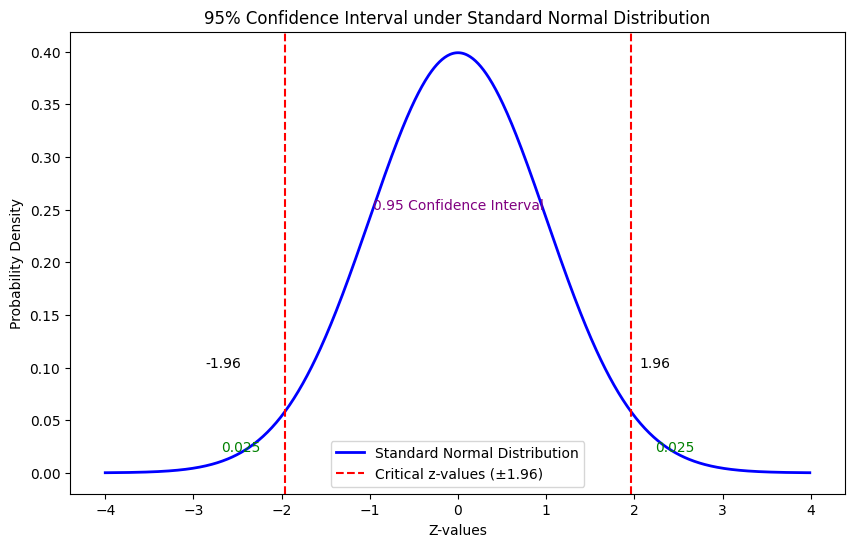

In [14]:
#Plot 95% Confidence Interval
import matplotlib.pyplot as plt
#X-axis values
x = np.arange(-4,4,0.01)
#Standard Normal PDF
y = norm.pdf(x)
#critical z value for 95% confidence
z_crit = 1.96
#Shading the area under the curve for 95% CI
plt.figure(figsize=(10,6))
plt.plot(x,y, label='Standard Normal Distribution', color='blue',linewidth=2)
#Vertical lines for critical z values
plt.axvline(-z_crit, color='red', linestyle='--', label='Critical z-values (±1.96)')
plt.axvline(z_crit, color='red', linestyle='--')

#text labels
plt.text(-z_crit-0.5, 0.1, '-1.96', ha = 'right')
plt.text(z_crit+0.1, 0.1, '1.96', ha = 'left')

#Tail probabilities 0.025 in each tail
plt.text(-z_crit-0.5, 0.02, '0.025', ha='center', color='green')
plt.text(z_crit+0.5, 0.02, '0.025', ha='center', color='green')

#Center confidence area
plt.text(0,0.25,"0.95 Confidence Interval", ha='center', color='purple')
plt.title('95% Confidence Interval under Standard Normal Distribution')
plt.xlabel('Z-values')
plt.ylabel('Probability Density')
plt.legend()
plt.show()